# Example: Quadratic local parameterisation


Parameterisation example is quadratic local with mean Antarctic slope (= no slope dependency) as defined in Burgard et al. (2022).


Based on code initially created by Clara Burgard, modfied and extended by Ronja Reese. Please note that we create the melt rates here, whereas in MeltMIP/ISMIP7 we ask modellers to use their parameterisation implemented in the ice sheet model to produce melt rates for parameter selection.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import multimelt.melt_functions as meltf
from multimelt.constants import *

from parameter_selection_toolbox_v2 import *

2026-04-17 17:18:11.187131: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-17 17:18:11.195402: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-17 17:18:11.476368: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-17 17:18:13.256855: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

# Settings

In [3]:
# Directories
figure_dir = 'figures'
#data_path="[your_path_to_ismip]/ISMIP7/parameterisations/ocean/"
data_path="/media/NAS2/ISMIP7/share_with_modellers"


# Constants
ice_density = 918 # [kg/m3]
reso=8000 # model resolution used for melt parameterisation [m]

# Create data 
Note that this would be replaced with running your melt parameterisation. 

In [4]:
# Create parameter array
# Good set of K
K = xr.DataArray(data=np.arange(0.25e-5,3.025e-4,0.25e-5), dims=['K_dim']).assign_coords({'K_dim': np.arange(0.25e-5,3.025e-4,0.25e-5)}) 

# Simple set of K
#K = xr.DataArray(data=np.arange(1.0e-5,3.6e-4,1e-5), dims=['K_dim']).assign_coords({'K_dim': np.arange(1.0e-5,3.6e-4,1e-5)}) 

# Expanded set of K
#K = xr.DataArray(data=np.arange(1.0e-6,3.06e-4,1e-6), dims=['K_dim']).assign_coords({'K_dim': np.arange(1.0e-6,3.06e-4,1e-6)}) 

K

<xarray.DataArray (K_dim: 120)> Size: 960B
array([2.500e-06, 5.000e-06, 7.500e-06, 1.000e-05, 1.250e-05, 1.500e-05,
       1.750e-05, 2.000e-05, 2.250e-05, 2.500e-05, 2.750e-05, 3.000e-05,
       3.250e-05, 3.500e-05, 3.750e-05, 4.000e-05, 4.250e-05, 4.500e-05,
       4.750e-05, 5.000e-05, 5.250e-05, 5.500e-05, 5.750e-05, 6.000e-05,
       6.250e-05, 6.500e-05, 6.750e-05, 7.000e-05, 7.250e-05, 7.500e-05,
       7.750e-05, 8.000e-05, 8.250e-05, 8.500e-05, 8.750e-05, 9.000e-05,
       9.250e-05, 9.500e-05, 9.750e-05, 1.000e-04, 1.025e-04, 1.050e-04,
       1.075e-04, 1.100e-04, 1.125e-04, 1.150e-04, 1.175e-04, 1.200e-04,
       1.225e-04, 1.250e-04, 1.275e-04, 1.300e-04, 1.325e-04, 1.350e-04,
       1.375e-04, 1.400e-04, 1.425e-04, 1.450e-04, 1.475e-04, 1.500e-04,
       1.525e-04, 1.550e-04, 1.575e-04, 1.600e-04, 1.625e-04, 1.650e-04,
       1.675e-04, 1.700e-04, 1.725e-04, 1.750e-04, 1.775e-04, 1.800e-04,
       1.825e-04, 1.850e-04, 1.875e-04, 1.900e-04, 1.925e-04, 1.950e-04,
       1.975e-04, 2.000e-04, 2.025e-04, 2.050e-04, 2.075e-04, 2.100e-04,
       2.125e-04, 2.150e-04, 2.175e-04, 2.200e-04, 2.225e-04, 2.250e-04,
       2.275e-04, 2.300e-04, 2.325e-04, 2.350e-04, 2.375e-04, 2.400e-04,
       2.425e-04, 2.450e-04, 2.475e-04, 2.500e-04, 2.525e-04, 2.550e-04,
       2.575e-04, 2.600e-04, 2.625e-04, 2.650e-04, 2.675e-04, 2.700e-04,
       2.725e-04, 2.750e-04, 2.775e-04, 2.800e-04, 2.825e-04, 2.850e-04,
       2.875e-04, 2.900e-04, 2.925e-04, 2.950e-04, 2.975e-04, 3.000e-04])
Coordinates:
  * K_dim    (K_dim) float64 960B 2.5e-06 5e-06 7.5e-06 ... 0.0002975 0.0003

In [5]:
# Load climatology
# path will be: /ISMIP7/AIS/obs/ocean/climatology/zhou_annual_06_nov/[so/tf/thetao]/v3/
climatology = xr.load_dataset(os.path.join(data_path, "climatology", "zhou_annual_06_nov", "OI_Climatology_ismip8km_60m_tf_extrap.nc"))
salinity = xr.load_dataset(os.path.join(data_path, "climatology", "zhou_annual_06_nov","OI_Climatology_ismip8km_60m_so_extrap.nc"))

# Load BedMap3
# path will be: /ISMIP7/AIS/obs/ocean/topography/
bed = xr.load_dataset(os.path.join(data_path, "topography", "bedmap3_ismip_8km.nc"))

# Load imbie2 basins as used on ISMIP
# path will be /ISMIP7/AIS/obs/ocean/IMBIE-basins/v3/IMBIE-basins_AIS_obs_ocean_v3.nc
basins = xr.load_dataset(os.path.join(data_path, 'imbie2', "basin_numbers_ismip8km_v2.nc"))
basins = basins.rename({'basinNumber':'basins'}) # basins start at 0
nBasins = int(basins.basins.max())

In [6]:
# Present-day melt rates

model_runs = [] 
p1s = []


# get thermal forcing at the ice shelf draft
tf_draft = climatology.tf.sel(z=bed['draft'], method='nearest')
tf_draft = tf_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
so_draft = salinity.so.sel(z=bed['draft'], method='nearest')
#so_draft = so_draft.where(so_draft>0, 0) # remove negative values
S0 = so_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
U_factor = (c_po / L_i) * beta_coeff_lazero * (g/(2*abs(f_coriolis))) * S0

for i,k in enumerate(K):

    p1s.append(k)
    
    thermal_forcing = (tf_draft).where(bed.floating_frac>0.5, np.nan)
    # melt rates in kg/m2/a
    ds = meltf.quadratic_mixed_slope(k, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density
    model_runs.append(ds)

print('Combining datasets')
pd_ensemble = xr.concat(model_runs, dim='K_dim')

pd_ensemble = pd_ensemble.rename({'K_dim':'p1'})
pd_ensemble = pd_ensemble.expand_dims({"p2": np.ones(1)})

pd_ensemble.name = "melt_rate"
pd_ensemble = pd_ensemble.to_dataset()

Combining datasets


In [7]:
# Ocean Modelling 

def apply_ocean_modelling_melt(model_names):
    ensembles = []
    
    for j,model in enumerate(model_names):
        print(model)
        try:
            # Path will be os.path.join(data_path,"ocean_modelling_data",model+"TF.nc") 
            ocean_modelling_data = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Modelling_Data",model+"TF.nc"))
        except:
            # FIXME REMOVE THIS ONCE DATA IS FINALISED
            ocean_modelling_data = xr.load_dataset("/media/NAS2/ISMIP7/Tocheck/output/"+model+"TF.nc")
            
        # get thermal forcing at the ice shelf draft
        tf_draft_om = ocean_modelling_data.thermal_forcing.sel(z=bed['draft'], method='nearest')
        tf_draft_om = tf_draft_om.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
        try:
            # Path will be os.path.join(data_path,"ocean_modelling_data",model+"S.nc") 
            salinity = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Modelling_Data",model+"S.nc"))
        except:
            salinity = xr.load_dataset("/media/NAS2/ISMIP7/Tocheck/output/"+model+"S.nc")
        # get thermal forcing at the ice shelf draft
        so_draft = salinity.salinity_ocean.sel(z=bed['draft'], method='nearest')
        S0 = so_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
        
        U_factor = (c_po / L_i) * beta_coeff_lazero * (g/(2*abs(f_coriolis))) * S0
    
        model_runs = []
        for i,k in enumerate(K):
            thermal_forcing = (tf_draft_om).where(bed.floating_frac>0.5, np.nan)        
            ds = meltf.quadratic_mixed_slope(k, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density
            model_runs.append(ds)
    
        print('Combining datasets')
        
        ensemble = xr.concat(model_runs, dim='K_dim')
        ensemble = ensemble.rename({'K_dim':'p1'})
        ensemble = ensemble.expand_dims({"p2": np.ones(1)})
        ensemble = ensemble.expand_dims({"model": np.array([j])})
        ensembles.append(ensemble)
        
    result = xr.concat(ensembles, dim='model')
    return result


# Save all modelling data into xarray dataset

model_names = ['Mathiot_NEMO_cold_v2_', "Timmermann_FESOM_cold_v2_", "Naughten_FESOM_ACCESS_cold_", "Naughten_FESOM_MMM_cold_",
              'Naughten_MITgcmASE_ens01_cold_', 'Naughten_MITgcmASE_ens02_cold_', 'Naughten_MITgcmASE_ens03_cold_', 
               'Naughten_MITgcmASE_ens04_cold_','Naughten_MITgcmASE_ens05_cold_', 'Naughten_MITgcmASE_ens06_cold_', 
               'Naughten_MITgcmASE_ens07_cold_', 'Naughten_MITgcmASE_ens08_cold_', 'Naughten_MITgcmASE_ens09_cold_', 
               'Naughten_MITgcmASE_ens10_cold_', 'Naughten_MITgcmWS_1pctCO2_cold_', 'Naughten_MITgcmWS_4xCO2_cold_' ]
cold_ensemble = apply_ocean_modelling_melt(model_names)
cold_ensemble = cold_ensemble.assign_coords(model=["mathiot", "timmermann", "naughten_ais_1", "naughten_ais_2",
                                              "naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
                                              "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
                                              "naughten_ase_9","naughten_ase_10","naughten_ws_1", "naughten_ws_2"])
cold_ensemble.name = "melt_rate"
cold_ensemble = cold_ensemble.to_dataset()

model_names = [name.replace('cold', 'warm') for name in model_names]
warm_ensemble = apply_ocean_modelling_melt(model_names)
warm_ensemble = warm_ensemble.assign_coords(model=["mathiot", "timmermann", "naughten_ais_1", "naughten_ais_2",
                                              "naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
                                              "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
                                              "naughten_ase_9","naughten_ase_10","naughten_ws_1", "naughten_ws_2"])
warm_ensemble.name = "melt_rate"
warm_ensemble = warm_ensemble.to_dataset()


Mathiot_NEMO_cold_v2_
Combining datasets
Timmermann_FESOM_cold_v2_
Combining datasets
Naughten_FESOM_ACCESS_cold_
Combining datasets
Naughten_FESOM_MMM_cold_
Combining datasets
Naughten_MITgcmASE_ens01_cold_
Combining datasets
Naughten_MITgcmASE_ens02_cold_
Combining datasets
Naughten_MITgcmASE_ens03_cold_
Combining datasets
Naughten_MITgcmASE_ens04_cold_
Combining datasets
Naughten_MITgcmASE_ens05_cold_
Combining datasets
Naughten_MITgcmASE_ens06_cold_
Combining datasets
Naughten_MITgcmASE_ens07_cold_
Combining datasets
Naughten_MITgcmASE_ens08_cold_
Combining datasets
Naughten_MITgcmASE_ens09_cold_
Combining datasets
Naughten_MITgcmASE_ens10_cold_
Combining datasets
Naughten_MITgcmWS_1pctCO2_cold_
Combining datasets
Naughten_MITgcmWS_4xCO2_cold_
Combining datasets
Mathiot_NEMO_warm_v2_
Combining datasets
Timmermann_FESOM_warm_v2_
Combining datasets
Naughten_FESOM_ACCESS_warm_
Combining datasets
Naughten_FESOM_MMM_warm_
Combining datasets
Naughten_MITgcmASE_ens01_warm_
Combining datas

In [8]:
# set outside of Weddell Sea to nan
for model in ["timmermann","naughten_ws_1", "naughten_ws_2"]:
    cold_ensemble = cold_ensemble.where( (cold_ensemble.model!=model )| (basins.basins == 14), np.nan)
    warm_ensemble = warm_ensemble.where( (warm_ensemble.model!=model )| (basins.basins == 14), np.nan)


# set outside of ASE to nan
for model in ["naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
             "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
             "naughten_ase_9","naughten_ase_10",]:
    cold_ensemble = cold_ensemble.where( (cold_ensemble.model!=model )| (basins.basins == 9), np.nan)
    warm_ensemble = warm_ensemble.where( (warm_ensemble.model!=model )| (basins.basins == 9), np.nan)

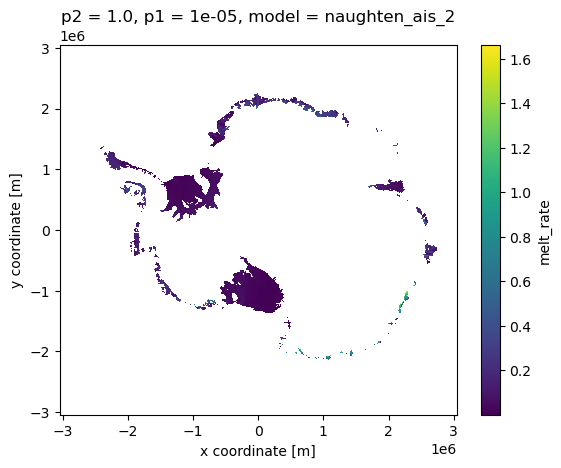

In [9]:
(cold_ensemble.sel(model='naughten_ais_2',p1=1e-5,p2=1).melt_rate/ice_density).plot()

In [10]:
# Ocean observations

def apply_ocean_observations_melt(dataset, years):
    ensembles = []
    for year in years:
        print(year)
        # Path will be os.path.join(data_path,"ocean_observations_data",model+"TF.nc") 
        ocean_data = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Observations_Data",dataset+"_tf_"+str(year)+".nc"))
    
        # get thermal forcing at the ice shelf draft
        tf_draft_om = ocean_data.tf.sel(z=bed['draft'], method='nearest')
        tf_draft_om = tf_draft_om.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
    
        salinity = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Observations_Data",dataset+"_so_"+str(year)+".nc"))
        # get thermal forcing at the ice shelf draft
        so_draft = salinity.so.sel(z=bed['draft'], method='nearest')
        S0 = so_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
        
        U_factor = (c_po / L_i) * beta_coeff_lazero * (g/(2*abs(f_coriolis))) * S0
    
        model_runs = []
        for i,k in enumerate(K):
            thermal_forcing = (tf_draft_om).where(bed.floating_frac>0.5, np.nan)        
            ds = meltf.quadratic_mixed_slope(k, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density
            model_runs.append(ds)
    
        print('Combining datasets')
        
        ensemble = xr.concat(model_runs, dim='K_dim')
        #print(ensemble)
        ensemble = ensemble.rename({'K_dim':'p1'})
        ensemble = ensemble.expand_dims({"p2": np.ones(1)})
        ensemble = ensemble.expand_dims({"year": np.array([year])})
        ensembles.append(ensemble)
    result = xr.concat(ensembles, dim='year')
    return result


years = np.array([1994, 2000, 2006, 2007, 2009,2010,2011,2012,2014,2016,2018,2019,2020]) # Use all years
obs_ensemble = apply_ocean_observations_melt("Dutrieux_ismip8km_60m",years)
obs_ensemble.name = "melt_rate"
obs_ensemble = obs_ensemble.to_dataset()


1994
Combining datasets
2000
Combining datasets
2006
Combining datasets
2007
Combining datasets
2009
Combining datasets
2010
Combining datasets
2011
Combining datasets
2012
Combining datasets
2014
Combining datasets
2016
Combining datasets
2018
Combining datasets
2019
Combining datasets
2020
Combining datasets


# Load modellers provided data

In [11]:
# Load your ensemble here

In [12]:
# load basins here at model grid resolution
model_reso = '8km'
basins_m = xr.load_dataset(os.path.join(data_path, 'imbie2', "basin_numbers_ismip"+model_reso+"_v2.nc"))
basins_m = basins_m.rename({'basinNumber':'basins'}) # basins start at 0

# load buttressing bins at model grid resolution
# path will be without "parameterisations"
bfrn_m = xr.load_dataset(os.path.join(data_path, 'parameterisations',"bfrns","BFRN_ismip"+model_reso+"_v2.nc"))

# load mask that is 1 if ice is floating and 0 if grounded on model grid resolution
# path will be without "parameterisations"
mask_m = xr.load_dataset(os.path.join(data_path, "parameterisations", "floatingmasks", "floatingmask_ismip"+model_reso+".nc")).mask

# Load data for optimisation

In [13]:
# Ice shelf masks for PIG and Dotson for term 4

# path will be without "parameterisations"
ds = xr.load_dataset(os.path.join(data_path, 'parameterisations',"shelfmask", "shelf_mask_ismip8km.nc"))#.isel(time=0)
shelves = ds.shelf_mask.isel(time=0)
pig_id = 110
dis_id = 97
pig = (shelves==pig_id)
dotson = (shelves==dis_id) 
pigdotson_mask = pig.astype(int) + dotson.astype(int) * 2
label_map = {1: "pig", 2: "dotson"}
labels = np.vectorize(label_map.get)(pigdotson_mask.values)
region_label = xr.DataArray(labels, dims=pigdotson_mask.dims, coords=pigdotson_mask.coords)

In [14]:
# Interpolate to model resolution
pigdotson_mask_m = pigdotson_mask.interp(method='nearest')
labels = np.vectorize(label_map.get)(pigdotson_mask_m.values)
region_label_m = xr.DataArray(labels, dims=pigdotson_mask_m.dims, coords=pigdotson_mask_m.coords)

# Load melt rate targets

In [15]:
# path will be without "parameterisations"

MeltDataImbie = pd.read_csv(os.path.join(data_path, 'parameterisations','meltobs','Melt_Paolo_Err_Adusumilli_imbie2_v2.csv'), index_col=0) # Aggregated per imbier basin

buttressing_target = xr.load_dataset(os.path.join(data_path, 'parameterisations', "meltobs","melt_target_term2.nc"))

cold_target = xr.load_dataset(os.path.join(data_path, 'parameterisations',"Ocean_Modelling_Data","melt_cold_target_term3.nc"))
warm_target = xr.load_dataset(os.path.join(data_path, 'parameterisations',"Ocean_Modelling_Data","melt_warm_target_term3.nc"))

t4_obs = xr.load_dataset(os.path.join(data_path, 'parameterisations',"Ocean_Observations_Data","melt_observations_target_term4.nc"))

# Calculate Terms 

In [16]:
cvt_m = reso**2  / 1e12  # to convert to Gt/a
cvt = 8000**2  / 1e12  # to convert to Gt/a

In [17]:
# Term 1
t1_model, t1_obs_mean, t1_obs_sigma = calculate_term1(
    pd_ensemble,mask_m,basins_m['basins'],nBasins,cvt_m,MeltDataImbie)

In [18]:
# Term 2
t2_model, t2_obs_mean, t2_obs_sigma = calculate_term2(
    pd_ensemble,mask_m,bfrn_m,cvt_m,buttressing_target)

In [19]:
# Term 3
t3_model, t3_obs_mean, t3_obs_sigma = calculate_term3(
    cold_ensemble, warm_ensemble, cold_target, warm_target,
    mask_m,basins_m['basins'])

In [20]:
# Term 4
t4_model, t4_obs_mean, t4_obs_sigma = calculate_term4(obs_ensemble, region_label_m, t4_obs, mask_m, cvt_m)

# Introduce weights

In [22]:
#(basins.basins==4).plot()

In [23]:
t1_weights = xr.DataArray(
    t1_obs_mean*0+1,
    dims=["basins"],
    coords={"basins": t1_model.basins.values}
)

# e.g., to sample only FRIS, Ross, Totten and ASE
#t1_weights = t1_weights.where( (t1_weights.basins==9) | 
#                               (t1_weights.basins==14) | 
#                               (t1_weights.basins==7) |
#                               (t1_weights.basins==4), 0)

# e.g., only ASE
#t1_weights = t1_weights.where( (t1_weights.basins==9), 0)

# to remove the term 1 
#t1_weights = t1_weights*0

In [24]:
# Buttressing Flux Response Numbers, remapped to 8km 
# Remove parameterisations from path
bfrn = xr.load_dataset(os.path.join(data_path, 'parameterisations', "bfrns", "BFRN_ismip8km_v2.nc"))

t2_weight = (bfrn['BFRN_medians'] / bfrn['BFRN_median']).values

t2_weights = xr.DataArray(
    t2_weight,
    dims=["BFRN_bins"],
    coords={"BFRN_bins": t2_obs_mean.BFRN_bins.values}
)

# to remove the term 2
#t2_weights = t2_weights*0

In [25]:
weights_data = np.ones(t3_model.isel(p1=0,p2=0).shape) 

t3_weights = xr.DataArray(
    weights_data,
    dims=["model", "basins"],
    coords={"model": t3_obs_mean.model.values,
            "basins": t3_obs_mean.basins.values}
)

# only use mathiot, and naughten_ais_1
t3_weights = t3_weights.where((t3_weights.model == "mathiot") | (t3_weights.model == "naughten_ais_1"), other=0)

# Test other weights, for example:
#t3_weights = t3_weights.where(t3_weights.model == "timmermann", other=0)
# sample only FRIS, Ross, and Totten, ASE
#t3_weights = t3_weights.where( (t1_weights.basins==9) | 
#                               (t1_weights.basins==14) | 
#                               (t1_weights.basins==7) |
#                               (t1_weights.basins==4), other=0)
#
# Only sample Amundsen Sea
#t3_weights = t3_weights.where( (t1_weights.basins==9) , other=0)
#
# Remove term 3 completely
#t3_weights = t3_weights*0

In [26]:
weights_data = np.ones(t4_model.isel(p1=0,p2=0).shape)

t4_weights = xr.DataArray(
    weights_data,
    dims=["year", "region"],
    coords={"year": t4_obs.year.values,
            "region": t4_obs.region.values}
)

# Only sample PIG in 2009 and 2012
t4_weights = t4_weights.where(t4_weights.region == "pig", other=0)
t4_weights = t4_weights.where((t4_weights.year ==2009) | (t4_weights.year==2012)  ,other=0)


# Test others
#t4_weights = t4_weights.where(t4_weights.region == "dotson", other=0)
# where both datasets have data
#t4_weights = t4_weights.where( (t4_weights.year ==2007) | (t4_weights.year==2009) |  (t4_weights.year==2012) |(t4_weights.year==2014) |
#                         (t4_weights.year==2016) ,other=0)
#year = 2020 #
#t4_weights = t4_weights.where( t4_weights.year ==year ,other=0)
# remove term 4
#t4_weights  = t4_weights *0

# Calculate objective function 

In [27]:
sample_size=100000

min_p1, min_p2 = calculate_objective_function(
    sample_size,
    reso,
    t1_model, t1_obs_mean, t1_obs_sigma,t1_weights,
    t2_model, t2_obs_mean, t2_obs_sigma,t2_weights,
    t3_model, t3_obs_mean, t3_obs_sigma,t3_weights,
    t4_model, t4_obs_mean, t4_obs_sigma,t4_weights)

Text(0, 0.5, 'Relative frequency')

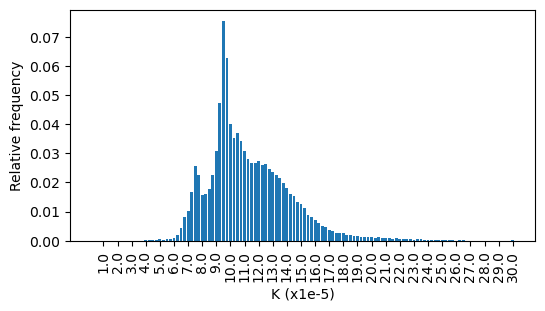

In [42]:
# PLOT
fig,axes = plt.subplots(1,1, sharex=False, sharey=False, figsize=(6,3))
ax = axes

bin_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+1e-7) )
counts, bins = np.histogram(np.array(min_p1), bins= bin_edges)
positions = np.arange(len(pd_ensemble.p1.values))
ax.bar(positions, counts/sample_size, width=0.8)   
labels = np.round(pd_ensemble.p1.values*1e5, 1)
ax.set_xticks(positions[3::4], labels[3::4], rotation=90)
ax.set_xlabel('K (x1e-5)')
ax.set_ylabel('Relative frequency')


In [33]:
# Find min, max, 5th, 95th, and modes

print('Start exploring median or mode:')
print('median = ', np.median(min_p1))
print('mode = ', pd_ensemble.p1.values[np.argmax(counts) ])


print('Uncertainty bounds:')
print('5th = ', np.percentile(np.array(min_p1), 5))
print('95th = ', np.percentile(np.array(min_p1), 95))


print('Further options for uncertainty exploration:')
print('min = ', np.min(np.array(min_p1)))
print('1st = ', np.percentile(np.array(min_p1), 1))
print('99th = ', np.percentile(np.array(min_p1), 99))
print('max = ', np.max(np.array(min_p1)))

vals = [#np.min(np.array(min_p1)), np.percentile(np.array(min_p1), 1), 
        np.percentile(np.array(min_p1), 5), np.median(np.array(min_p1)), 
        np.percentile(np.array(min_p1), 95),# np.percentile(np.array(min_p1), 99),
        #np.max(np.array(min_p1))
       ]
labs = [#'min', '1st', 
    '5th', '50th', '95th', '99th', 'max']


# Find local maxima for modes, 
peaks, _ = find_peaks(counts)
modes = pd_ensemble.p1.values[peaks]
print('Modes = ', modes)

Start exploring median or mode:
median =  0.00010750000000000001
mode =  9.500000000000002e-05
Uncertainty bounds:
5th =  7.500000000000001e-05
95th =  0.00016500000000000003
Further options for uncertainty exploration:
min =  2.5e-06
1st =  6.500000000000001e-05
99th =  0.00021000000000000004
max =  0.00030000000000000003
Modes =  [1.000e-05 2.500e-05 3.000e-05 3.500e-05 5.000e-05 7.500e-05 9.500e-05
 1.050e-04 1.200e-04 1.250e-04 1.800e-04 1.975e-04 2.050e-04 2.175e-04
 2.250e-04 2.325e-04 2.400e-04 2.525e-04 2.650e-04 2.700e-04 2.750e-04
 2.875e-04]


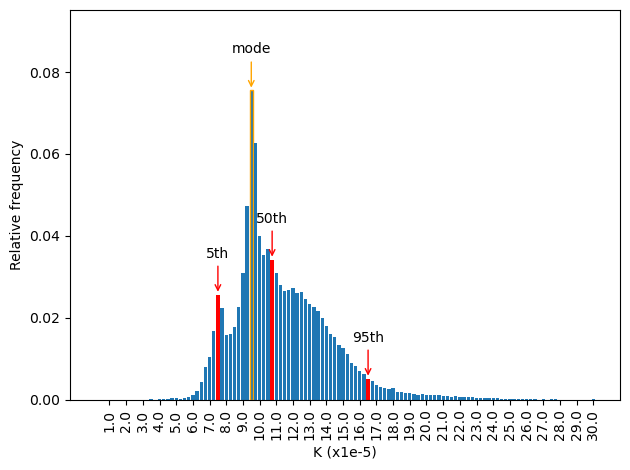

In [55]:
fig,axes = plt.subplots(1,1, sharex=False, sharey=False)
ax = axes

bin_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+1e-7) )
counts, bins = np.histogram(np.array(min_p1), bins= bin_edges)
positions = np.arange(len(pd_ensemble.p1.values))
ax.bar(positions, counts/sample_size, width=0.8)
#ax.set_ylim([0,350])
for i,val in enumerate(vals):
    bin_index = np.digitize(val, bin_edges) - 1
    ax.patches[bin_index].set_facecolor('red')
    bin_center = bin_index #(bin_edges[bin_index] + bin_edges[bin_index+1]) / 2
    plt.annotate(labs[i], xy=(bin_center, counts[bin_index]/sample_size), 
                 xytext=(bin_center, (counts[bin_index]+1000)/sample_size),
                 ha='center', va='center',
                 arrowprops=dict(arrowstyle='->', color='red'))

for mode in [pd_ensemble.p1.values[np.argmax(counts) ]]: #modes[:1]:
    bin_index = np.digitize(mode, bin_edges) - 1 # FIXME this is not working!
    ax.patches[bin_index].set_edgecolor('orange')
    bin_center = bin_index 
    plt.annotate('mode', xy=(bin_center, counts[bin_index]/sample_size), 
                 xytext=(bin_center, (counts[bin_index]+1000)/sample_size),
                ha='center', va='center',
                 arrowprops=dict(arrowstyle='->', color='orange'))

labels = np.round(pd_ensemble.p1.values*1e5, 1)
ax.set_xticks(positions[3::4], labels[3::4], rotation=90)
ax.set_xlabel('K (x1e-5)')
ax.set_ylabel('Relative frequency')
ymax = ax.get_ylim()[1]
ax.set_ylim(0, ymax * 1.2)  

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_sample10e5.png'))   


# Alternative sampling, only using Amundsen Sea data

In [57]:
t1_weights = xr.DataArray(
    t1_obs_mean*0+1,
    dims=["basins"],
    coords={"basins": t1_model.basins.values}
)

# e.g., only ASE
t1_weights = t1_weights.where( (t1_weights.basins==9), 0)

In [77]:
# Buttressing Flux Response Numbers, remapped to 8km 
# Remove parameterisations from path
bfrn = xr.load_dataset(os.path.join(data_path, 'parameterisations', "bfrns", "BFRN_ismip8km_v2.nc"))

t2_weight = (bfrn['BFRN_medians'] / bfrn['BFRN_median']).values

t2_weights = xr.DataArray(
    t2_weight,
    dims=["BFRN_bins"],
    coords={"BFRN_bins": t2_obs_mean.BFRN_bins.values}
)

# to remove the term 2
t2_weights = t2_weights*0

In [78]:
weights_data = np.ones(t3_model.isel(p1=0,p2=0).shape) 

t3_weights = xr.DataArray(
    weights_data,
    dims=["model", "basins"],
    coords={"model": t3_obs_mean.model.values,
            "basins": t3_obs_mean.basins.values}
)

# only use mathiot, and naughten_ais_1
#t3_weights = t3_weights.where((t3_weights.model == "mathiot") | (t3_weights.model == "naughten_ais_1"), other=0)

# Only sample Amundsen Sea
t3_weights = t3_weights.where( (t1_weights.basins==9) , other=0)

In [79]:
weights_data = np.ones(t4_model.isel(p1=0,p2=0).shape)

t4_weights = xr.DataArray(
    weights_data,
    dims=["year", "region"],
    coords={"year": t4_obs.year.values,
            "region": t4_obs.region.values}
)

# Only sample PIG in 2009 and 2012
#t4_weights = t4_weights.where(t4_weights.region == "pig", other=0)
#t4_weights = t4_weights.where((t4_weights.year ==2009) | (t4_weights.year==2012)  ,other=0)


In [80]:
# Sample

In [86]:
sample_size=100000

min_p1, min_p2 = calculate_objective_function(
    sample_size,
    reso,
    t1_model, t1_obs_mean, t1_obs_sigma,t1_weights,
    t2_model, t2_obs_mean, t2_obs_sigma,t2_weights,
    t3_model, t3_obs_mean, t3_obs_sigma,t3_weights,
    t4_model, t4_obs_mean, t4_obs_sigma,t4_weights)

Text(0, 0.5, 'Relative frequency')

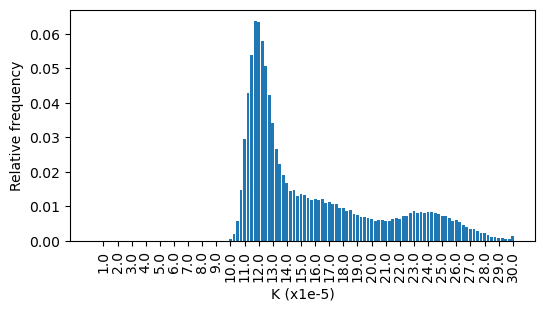

In [87]:
# PLOT
fig,axes = plt.subplots(1,1, sharex=False, sharey=False, figsize=(6,3))
ax = axes

bin_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+1e-7) )
counts, bins = np.histogram(np.array(min_p1), bins= bin_edges)
positions = np.arange(len(pd_ensemble.p1.values))
ax.bar(positions, counts/sample_size, width=0.8)   
labels = np.round(pd_ensemble.p1.values*1e5, 1)
ax.set_xticks(positions[3::4], labels[3::4], rotation=90)
ax.set_xlabel('K (x1e-5)')
ax.set_ylabel('Relative frequency')


In [88]:
# Find min, max, 5th, 95th, and modes

print('Start exploring median or mode:')
print('median = ', np.median(min_p1))
print('mode = ', pd_ensemble.p1.values[np.argmax(counts) ])


print('Uncertainty bounds:')
print('5th = ', np.percentile(np.array(min_p1), 5))
print('95th = ', np.percentile(np.array(min_p1), 95))


print('Further options for uncertainty exploration:')
print('min = ', np.min(np.array(min_p1)))
print('1st = ', np.percentile(np.array(min_p1), 1))
print('99th = ', np.percentile(np.array(min_p1), 99))
print('max = ', np.max(np.array(min_p1)))

vals = [#np.min(np.array(min_p1)), np.percentile(np.array(min_p1), 1), 
        np.percentile(np.array(min_p1), 5), np.median(np.array(min_p1)), 
        np.percentile(np.array(min_p1), 95),# np.percentile(np.array(min_p1), 99),
        #np.max(np.array(min_p1))
       ]
labs = [#'min', '1st', 
    '5th', '50th', '95th', '99th', 'max']


# Find local maxima for modes, 
peaks, _ = find_peaks(counts)
modes = pd_ensemble.p1.values[peaks]
print('Modes = ', modes)

Start exploring median or mode:
median =  0.00013500000000000003
mode =  0.00011750000000000001
Uncertainty bounds:
5th =  0.00011000000000000002
95th =  0.000255
Further options for uncertainty exploration:
min =  9.500000000000002e-05
1st =  0.00010750000000000001
99th =  0.0002775249999999869
max =  0.00030000000000000003
Modes =  [0.0001175 0.000145  0.00015   0.00016   0.000165  0.00017   0.00018
 0.000185  0.0002075 0.0002175 0.00023   0.000235  0.0002425 0.00026  ]


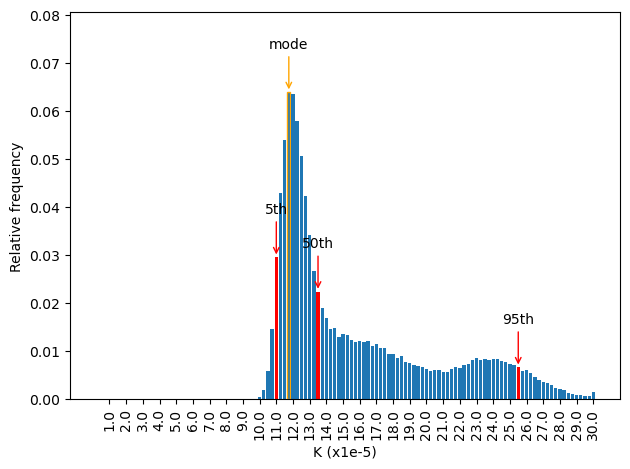

In [89]:
fig,axes = plt.subplots(1,1, sharex=False, sharey=False)
ax = axes

bin_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+1e-7) )
counts, bins = np.histogram(np.array(min_p1), bins= bin_edges)
positions = np.arange(len(pd_ensemble.p1.values))
ax.bar(positions, counts/sample_size, width=0.8)
#ax.set_ylim([0,350])
for i,val in enumerate(vals):
    bin_index = np.digitize(val, bin_edges) - 1
    ax.patches[bin_index].set_facecolor('red')
    bin_center = bin_index #(bin_edges[bin_index] + bin_edges[bin_index+1]) / 2
    plt.annotate(labs[i], xy=(bin_center, counts[bin_index]/sample_size), 
                 xytext=(bin_center, (counts[bin_index]+1000)/sample_size),
                 ha='center', va='center',
                 arrowprops=dict(arrowstyle='->', color='red'))

for mode in [pd_ensemble.p1.values[np.argmax(counts) ]]: #modes[:1]:
    bin_index = np.digitize(mode, bin_edges) - 1 # FIXME this is not working!
    ax.patches[bin_index].set_edgecolor('orange')
    bin_center = bin_index 
    plt.annotate('mode', xy=(bin_center, counts[bin_index]/sample_size), 
                 xytext=(bin_center, (counts[bin_index]+1000)/sample_size),
                ha='center', va='center',
                 arrowprops=dict(arrowstyle='->', color='orange'))

labels = np.round(pd_ensemble.p1.values*1e5, 1)
ax.set_xticks(positions[3::4], labels[3::4], rotation=90)
ax.set_xlabel('K (x1e-5)')
ax.set_ylabel('Relative frequency')
ymax = ax.get_ylim()[1]
ax.set_ylim(0, ymax * 1.2)  

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_sample10e5_ASE.png'))   


# Test optimal K values

Select a parameter value from above, e.g., the median or mode, and calculate deltaT to fit present-day, basin-wide melt (basically Term 1).

In [90]:
K = 0.0001075

In [91]:
# compare to gT from Jourdain et al., 20220

S0=34.5
sintheta = 2.9e-3
gT_to_K = 2*abs(f_coriolis)*rho_sw/(rho_i*g*beta_coeff_lazero*S0*sintheta*yearinsec)

print("This corresponds roughly to \gamma_T= ", np.round(K/gT_to_K), "m/a from Jourdain et al., 2020")

This corresponds roughly to \gamma_T=  8337.0 m/a from Jourdain et al., 2020


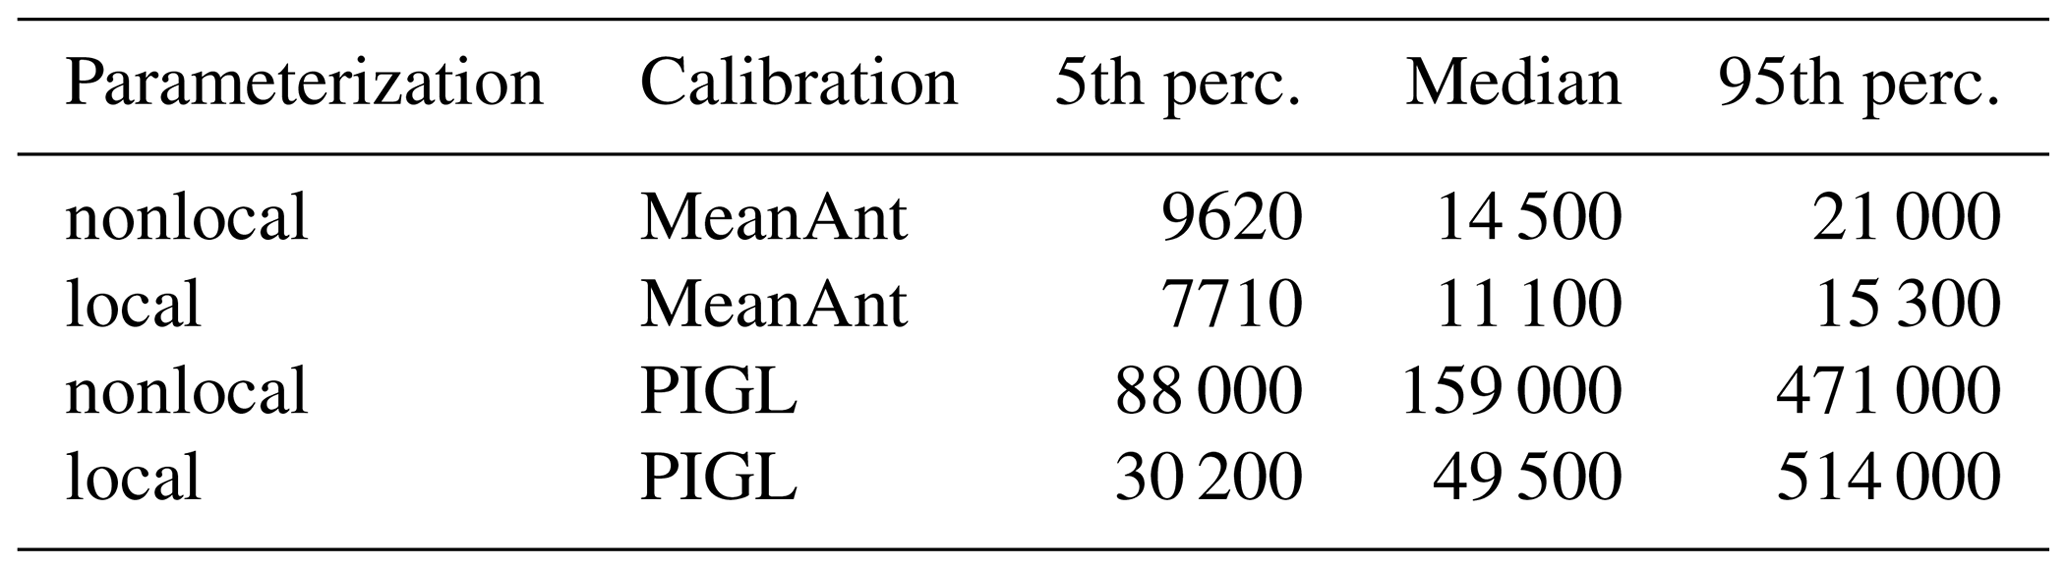

# Optimise deltaT - optional

First calculate melt rates with the chose K for a range of deltaT corrections (applied uniformly to the whole continent). Note that this should be done within the model parametererisation.

In [92]:
# Create deltaT corrections array
deltaT = np.linspace(-2,2,101) 

# calculate melt rates for uniform deltaT 
members = []
for dT in deltaT:      
    thermal_forcing = (tf_draft+dT).where(mask_m, np.nan)        
    ds = meltf.quadratic_mixed_slope(K, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density
    ds = ds.assign_coords(deltaT=dT)
    members.append(ds)
dT_ensemble = xr.concat(members, dim='deltaT', coords='minimal')

In [93]:
result_ds = optimise_deltaT(dT_ensemble, basins_m['basins'], reso,  MeltDataImbie)

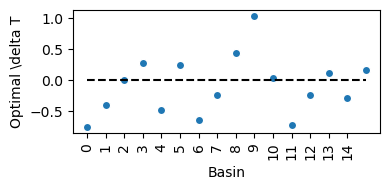

In [102]:
plt.figure(figsize=(4,2))
result_ds.optimal_deltaT_per_basin.plot.scatter()
plt.xticks(np.arange(0,nBasins), np.arange(0,nBasins), rotation=90)
plt.xlabel('Basin')
plt.ylabel('Optimal \delta T')
plt.hlines(0, 0, nBasins, color='black', linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_deltaT_'+str(K)+'.png'))   

In [103]:
# here we calculate melt rates, using deltaT for the ocean modelling data. This should be done with the melt parameterisation

def apply_deltaT_to_dataset(model_names, optimal_deltaT_per_basin):
    results = []
    
    for j,model in enumerate(model_names):
        print(model)
        
        number_of_basins = int(len(optimal_deltaT_per_basin))-1
        try:
            # for final path see above
            ocean_modelling_data = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Modelling_Data",model+"TF.nc"))
        except:
            # FIXME REMOVE THIS ONCE DATA IS FINALISED
            ocean_modelling_data = xr.load_dataset("/media/NAS2/ISMIP7/Tocheck/output/"+model+"TF.nc")
        # get thermal forcing at the ice shelf draft
        tf_draft_om = ocean_modelling_data.thermal_forcing.sel(z=bed['draft'], method='nearest')
        tf_draft_om = tf_draft_om.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
    
        try:
            ocean_modelling_data = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Modelling_Data",model+"S.nc"))# get thermal forcing at the ice shelf draft
        except:
            # FIXME REMOVE THIS ONCE DATA IS FINALISED
            ocean_modelling_data = xr.load_dataset("/media/NAS2/ISMIP7/Tocheck/output/"+model+"S.nc")
        so_draft = salinity.so.sel(z=bed['draft'], method='nearest')
        S0 = so_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
        
        U_factor = (c_po / L_i) * beta_coeff_lazero * (g/(2*abs(f_coriolis))) * S0
        
        thermal_forcing = (tf_draft_om).where(bed.floating_frac>0.5, np.nan)  
        
        # Create spatial field from your 1D array
        basins_to_value = xr.DataArray(optimal_deltaT_per_basin, dims=['basins'], coords={'basins': range(number_of_basins+1)})
        spatial_values = basins_to_value.sel(basins=basins['basins'])
    
        # Add to existing field
        thermal_forcing = thermal_forcing + spatial_values
        ds = meltf.quadratic_mixed_slope(K, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density
        
        ds = ds.expand_dims({"model": np.array([j])})
        results.append(ds)
        
    result = xr.concat(results, dim='model')
    return result



model_names = ['Mathiot_NEMO_cold_v2_', "Timmermann_FESOM_cold_v2_", "Naughten_FESOM_ACCESS_cold_", "Naughten_FESOM_MMM_cold_",
              'Naughten_MITgcmASE_ens01_cold_', 'Naughten_MITgcmASE_ens02_cold_', 'Naughten_MITgcmASE_ens03_cold_', 
               'Naughten_MITgcmASE_ens04_cold_','Naughten_MITgcmASE_ens05_cold_', 'Naughten_MITgcmASE_ens06_cold_', 
               'Naughten_MITgcmASE_ens07_cold_', 'Naughten_MITgcmASE_ens08_cold_', 'Naughten_MITgcmASE_ens09_cold_', 
               'Naughten_MITgcmASE_ens10_cold_', 'Naughten_MITgcmWS_1pctCO2_cold_', 'Naughten_MITgcmWS_4xCO2_cold_' ]
cold_results = apply_deltaT_to_dataset(model_names,result_ds.optimal_deltaT_per_basin.values)
cold_results = cold_results.assign_coords(model=["mathiot", "timmermann", "naughten_ais_1", "naughten_ais_2",
                                              "naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
                                              "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
                                              "naughten_ase_9","naughten_ase_10","naughten_ws_1", "naughten_ws_2"])
cold_results.name = "melt_rate"
cold_results = cold_results.to_dataset()

model_names = [name.replace('cold', 'warm') for name in model_names]
warm_results = apply_deltaT_to_dataset(model_names,result_ds.optimal_deltaT_per_basin.values)
warm_results = warm_results.assign_coords(model=["mathiot", "timmermann", "naughten_ais_1", "naughten_ais_2",
                                              "naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
                                              "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
                                              "naughten_ase_9","naughten_ase_10","naughten_ws_1", "naughten_ws_2"])
warm_results.name = "melt_rate"
warm_results = warm_results.to_dataset()

# replace warm and cold basins other than FRIS with NaN in TimmermannAndGoeller datasets
cold_results = cold_results.where( (cold_results.model!='timmermann' )| (basins.basins==14) , np.nan)
warm_results = warm_results.where( (warm_results.model!='timmermann' )| (basins.basins==14) , np.nan)



# set outside of Weddell Sea to nan
for model in ["timmermann","naughten_ws_1", "naughten_ws_2"]:
    cold_results = cold_results.where( (cold_results.model!=model )| (basins.basins == 14), np.nan)
    warm_results = warm_results.where( (warm_results.model!=model )| (basins.basins == 14), np.nan)


# set outside of ASE to nan
for model in ["naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
             "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
             "naughten_ase_9","naughten_ase_10",]:
    cold_results = cold_results.where( (cold_results.model!=model )| (basins.basins == 9), np.nan)
    warm_results = warm_results.where( (warm_results.model!=model )| (basins.basins == 9), np.nan)

Mathiot_NEMO_cold_v2_
Timmermann_FESOM_cold_v2_
Naughten_FESOM_ACCESS_cold_
Naughten_FESOM_MMM_cold_
Naughten_MITgcmASE_ens01_cold_
Naughten_MITgcmASE_ens02_cold_
Naughten_MITgcmASE_ens03_cold_
Naughten_MITgcmASE_ens04_cold_
Naughten_MITgcmASE_ens05_cold_
Naughten_MITgcmASE_ens06_cold_
Naughten_MITgcmASE_ens07_cold_
Naughten_MITgcmASE_ens08_cold_
Naughten_MITgcmASE_ens09_cold_
Naughten_MITgcmASE_ens10_cold_
Naughten_MITgcmWS_1pctCO2_cold_
Naughten_MITgcmWS_4xCO2_cold_
Mathiot_NEMO_warm_v2_
Timmermann_FESOM_warm_v2_
Naughten_FESOM_ACCESS_warm_
Naughten_FESOM_MMM_warm_
Naughten_MITgcmASE_ens01_warm_
Naughten_MITgcmASE_ens02_warm_
Naughten_MITgcmASE_ens03_warm_
Naughten_MITgcmASE_ens04_warm_
Naughten_MITgcmASE_ens05_warm_
Naughten_MITgcmASE_ens06_warm_
Naughten_MITgcmASE_ens07_warm_
Naughten_MITgcmASE_ens08_warm_
Naughten_MITgcmASE_ens09_warm_
Naughten_MITgcmASE_ens10_warm_
Naughten_MITgcmWS_1pctCO2_warm_
Naughten_MITgcmWS_4xCO2_warm_


In [104]:
# Apply deltaT to ocean observations term

def apply_deltaT_to_obsterm(dataset, years, optimal_deltaT_per_basin):
    results = []
    for j,year in enumerate(years):
        print(year)
        ocean_data = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Observations_Data",dataset+"_tf_"+str(year)+".nc"))
    
        # get thermal forcing at the ice shelf draft
        tf_draft_om = ocean_data.tf.sel(z=bed['draft'], method='nearest')
        tf_draft_om = tf_draft_om.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
    
        salinity = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Observations_Data",dataset+"_so_"+str(year)+".nc"))
        # get thermal forcing at the ice shelf draft
        so_draft = salinity.so.sel(z=bed['draft'], method='nearest')
        S0 = so_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
        
        U_factor = (c_po / L_i) * beta_coeff_lazero * (g/(2*abs(f_coriolis))) * S0
    
        # Create spatial field from your 1D array
        number_of_basins = int(len(optimal_deltaT_per_basin))-1
        basins_to_value = xr.DataArray(optimal_deltaT_per_basin, dims=['basins'], coords={'basins': range(number_of_basins+1)})
        spatial_values = basins_to_value.sel(basins=basins['basins'])
    
        # Add to existing field
        thermal_forcing = tf_draft_om + spatial_values
        ds = meltf.quadratic_mixed_slope(K, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density

        ds = ds.expand_dims({"year": np.array([year])})
        results.append(ds)
        
    result = xr.concat(results, dim='year')
        
    return result


years = np.array([1994, 2000, 2006, 2007, 2009,2010,2011,2012,2014,2016,2018,2019,2020]) # Use all years
obs_results = apply_deltaT_to_obsterm("Dutrieux_ismip8km_60m",years, result_ds.optimal_deltaT_per_basin.values)
obs_results.name = "melt_rate"
obs_results = obs_results.to_dataset()

1994
2000
2006
2007
2009
2010
2011
2012
2014
2016
2018
2019
2020


# Plot spatial melt rates 

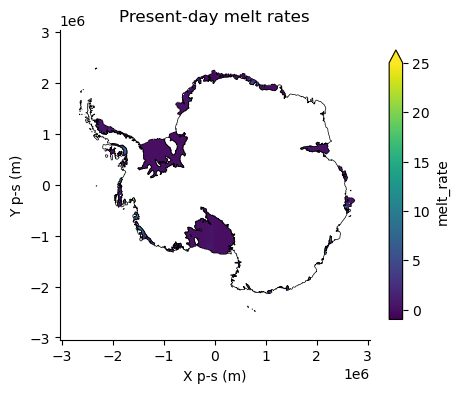

In [105]:
plt.figure(figsize=(5,5))

(result_ds.melt_rate/ice_density).plot( vmin=-1, vmax=25, cmap='viridis',cbar_kwargs={'shrink': 0.7} )
ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlabel('X p-s (m)')
ax.set_ylabel('Y p-s (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.contour(result_ds.x, result_ds.y, bed.ocean_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.contour(result_ds.x, result_ds.y, bed.floating_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.title('Present-day melt rates')

plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_presentdaymelt.png'))  

Text(0.5, 1.0, 'Mathiot NEMO cold melt rates')

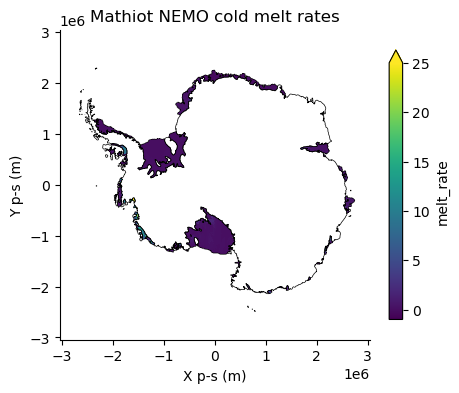

In [106]:
plt.figure(figsize=(5,5))

(cold_results.sel(model='mathiot').melt_rate/ice_density).plot(vmin=-1, vmax=25, cmap='viridis',cbar_kwargs={'shrink': 0.7} )
ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlabel('X p-s (m)')
ax.set_ylabel('Y p-s (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.contour(result_ds.x, result_ds.y, bed.ocean_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.contour(result_ds.x, result_ds.y, bed.floating_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.title('Mathiot NEMO cold melt rates')
#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_mathiotcoldmelt.png'))  

Text(0.5, 1.0, 'Mathiot NEMO warm melt rates')

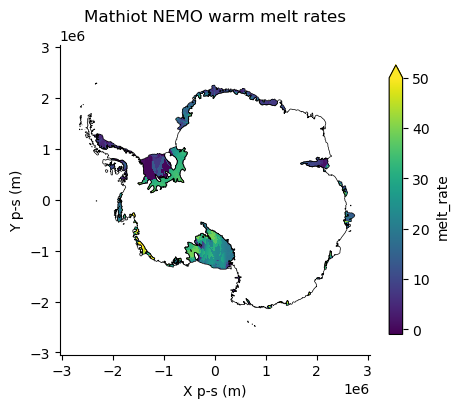

In [107]:
plt.figure(figsize=(5,5))

(warm_results.sel(model='mathiot').melt_rate/ice_density).plot( vmin=-1, vmax=50, cmap='viridis',cbar_kwargs={'shrink': 0.7} )
ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlabel('X p-s (m)')
ax.set_ylabel('Y p-s (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.contour(result_ds.x, result_ds.y, bed.ocean_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.contour(result_ds.x, result_ds.y, bed.floating_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.title('Mathiot NEMO warm melt rates')

#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_mathiotwarmmelt.png'))  

# Plot fit to individual terms

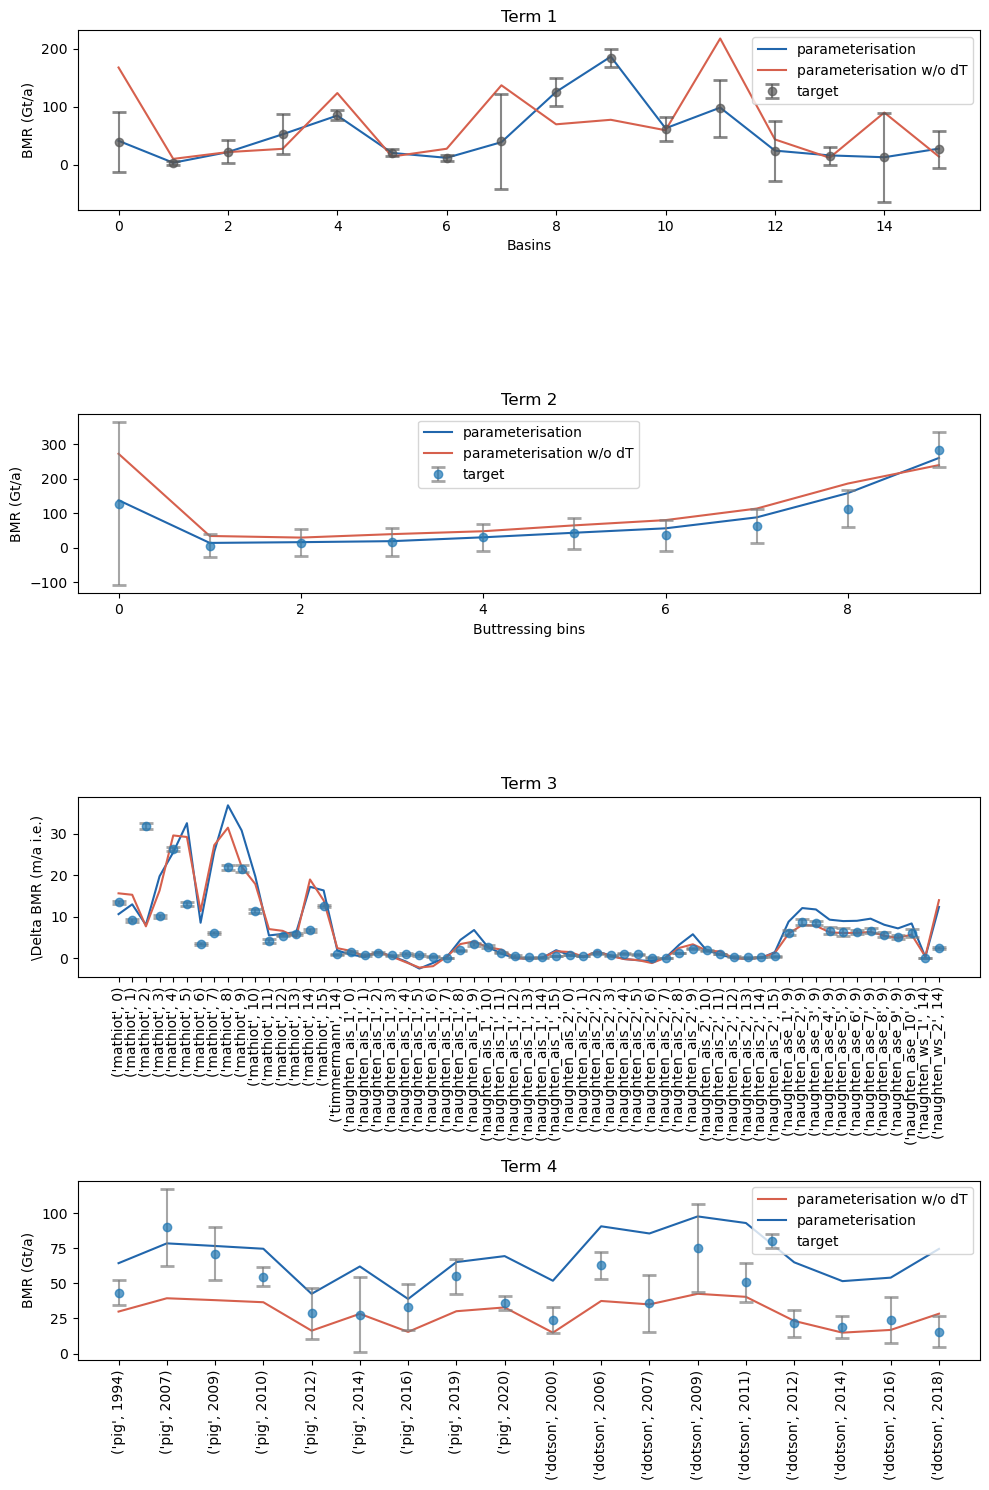

In [113]:
fig, axes = plt.subplots(4, 1, figsize=(10, 15))

color_wocorrection = "#D6604D"
color_wcorrection = "#2166AC"

# TERM 1
ax = axes[0]  

t1_model_ndT, t1_obs_mean_ndT, t1_obs_sigma_ndT = calculate_term1(
    pd_ensemble.sel(p1=K,p2=1, method='nearest'), mask_m, basins_m.basins, nBasins, cvt_m, MeltDataImbie)

t1_model_p, t1_obs_mean_p, t1_obs_sigma_p = calculate_term1(
    result_ds, mask_m, basins_m.basins, nBasins, cvt_m, MeltDataImbie)

ax.plot(range(nBasins+1),t1_model_p , label='parameterisation', color=color_wcorrection)
ax.plot(range(nBasins+1),t1_model_ndT , label='parameterisation w/o dT', color=color_wocorrection)
ax.errorbar(range(nBasins+1), t1_obs_mean, xerr=None, yerr=t1_obs_sigma, 
             fmt='o', capsize=5, capthick=2, color="#555555", 
             ecolor="#555555", alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Basins')
#plt.text(0,2, 'Modelled average melt = '+str(np.round(np.sum(t2_model).values))+' m/a' )
#plt.text(0,1, 'Observed average melt = '+str(np.round(np.sum(t2_obs_mean).values))+' m/a' )
ax.legend()
ax.set_title('Term 1')


# TERM 2
ax = axes[1]  
t2_model_ndT, t2_obs_mean_ndT, t2_obs_sigma_ndT = calculate_term2(
    pd_ensemble.sel(p1=K,p2=1, method='nearest'),mask_m,bfrn_m,cvt_m,buttressing_target)

t2_model_p, t2_obs_mean_p, t2_obs_sigma_p = calculate_term2(
    result_ds,mask_m,bfrn_m,cvt_m,buttressing_target)

ax.plot(range(len(t2_model.BFRN_bins)),t2_model_p , label='parameterisation', color=color_wcorrection)
ax.plot(range(len(t2_model.BFRN_bins)),t2_model_ndT , label='parameterisation w/o dT', color=color_wocorrection)
ax.errorbar(range(len(t2_model.BFRN_bins)), t2_obs_mean, xerr=None, yerr=t2_obs_sigma, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Buttressing bins')
ax.legend()
ax.set_title('Term 2')


# Term 3
ax = axes[2]  

t3_model_ndT, t3_obs_mean_ndT, t3_obs_sigma_ndT = calculate_term3(
    cold_ensemble.sel(p1=K,p2=1, method='nearest'), warm_ensemble.sel(p1=K,p2=1, method='nearest'), cold_target, warm_target, mask_m, basins_m.basins)

t3_model_p, t3_obs_mean_p, t3_obs_sigma_p = calculate_term3(
    cold_results,warm_results, cold_target, warm_target, mask_m, basins_m.basins)

t3_stack = t3_model_p.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')
t3_stack_ndT = t3_model_ndT.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')

ax.plot(range(len(t3_stack.modelbasin)),
        t3_stack/ice_density , label='parameterisation', color=color_wcorrection)
ax.plot(range(len(t3_stack_ndT.modelbasin)),
        t3_stack_ndT/ice_density , label='parameterisation w/o dT', color=color_wocorrection)
ax.errorbar(range(len(t3_stack_ndT.modelbasin)), 
            t3_obs_mean.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density, 
            xerr=None, yerr=t3_obs_sigma.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('\Delta BMR (m/a i.e.)')
ax.set_xticks(range(len(t3_stack.modelbasin)))
ax.set_xticklabels(t3_stack.modelbasin.values, rotation=90)
ax.set_title('Term 3')

## Term 4
ax = axes[3] 


t4_model_ndT, t4_obs_mean_ndT, t4_obs_sigma_ndT = calculate_term4(
    obs_ensemble.sel(p1=K,p2=1, method='nearest'), region_label_m, t4_obs, mask_m, cvt_m)

t4_model_p, t4_obs_mean_p, t4_obs_sigma_p = calculate_term4(
    obs_results, region_label_m, t4_obs, mask_m, cvt_m)


ds_flat_ndT = t4_model_ndT.stack(region_year=("region", "year")).dropna(dim='region_year')
ds_flat = t4_model_p.stack(region_year=("region", "year")).dropna(dim='region_year')


ax.plot(range(len(ds_flat_ndT.region_year)),ds_flat_ndT.values , label='parameterisation w/o dT', color=color_wocorrection)
ax.plot(range(len(ds_flat.region_year)),ds_flat.values , label='parameterisation', color=color_wcorrection)

ax.errorbar(range(len(ds_flat.region_year)), 
            t4_obs_mean.stack(region_year=('region','year')).dropna(dim='region_year'), 
            xerr=None, 
            yerr=t4_obs_sigma.stack(region_year=('region','year')).dropna(dim='region_year'),
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xticks(range(len(ds_flat.region_year)))
ax.set_xticklabels(ds_flat.region_year.values, rotation=90)
ax.set_title('Term 4')
ax.legend()

# Add overall title
#fig.suptitle('K='+str(K), fontsize=16)

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_Terms.png'))  

plt.show()